In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, cross_validate, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [38]:
df = pd.read_csv('lw3_test.csv', delimiter=';', encoding='utf-8')

print("Первые 10 строк данных:")
print(df.head(10))

print("\nИнформация о данных:")
print(df.info())

print("\nРаспределение по классам:")
print(df['class'].value_counts())

print(f"\nРазмер выборки: {df.shape[0]} строк, {df.shape[1]} столбцов")

Первые 10 строк данных:
   sweetness  crunch      class
0          7       7      fruit
1          2       5  vegetable
2          1       2    protein
3          9       1      fruit
4          1       5    protein
5          1       1    protein
6          1       1    protein
7          8       1      fruit
8          2       8  vegetable
9          6       1      fruit

Информация о данных:
<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   sweetness  40 non-null     int64
 1   crunch     40 non-null     int64
 2   class      40 non-null     str  
dtypes: int64(2), str(1)
memory usage: 1.1 KB
None

Распределение по классам:
class
protein      16
fruit        12
vegetable    12
Name: count, dtype: int64

Размер выборки: 40 строк, 3 столбцов


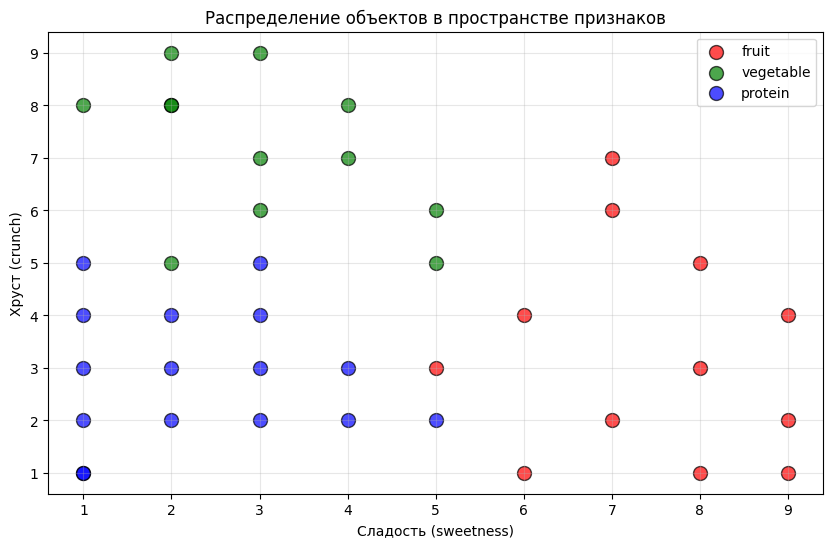

In [39]:
%matplotlib inline

plt.figure(figsize=(10, 6))

# Цвета для классов
colors = {'fruit': 'red', 'vegetable': 'green', 'protein': 'blue'}

for class_name, color in colors.items():
    subset = df[df['class'] == class_name]
    plt.scatter(subset['sweetness'], subset['crunch'], 
                c=color, label=class_name, alpha=0.7, s=100, edgecolors='black')

plt.xlabel('Сладость (sweetness)')
plt.ylabel('Хруст (crunch)')
plt.title('Распределение объектов в пространстве признаков')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [40]:
# Разделение на признаки и целевую переменную
X = df[['sweetness', 'crunch']].values
y = df['class'].values

# Нормализация признаков (для корректной работы KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Признаки (X) — первые 5 строк:")
print(X[:5])
print(f"\nЦелевая переменная (y): {np.unique(y)}")

Признаки (X) — первые 5 строк:
[[7 7]
 [2 5]
 [1 2]
 [9 1]
 [1 5]]

Целевая переменная (y): ['fruit' 'protein' 'vegetable']


In [41]:
%%time

# Параметры кросс-валидации
k_values = range(1, 20)
cv_folds = 5  # 5-кратная кросс-валидация

# Стратифицированная разбивка (сохраняет пропорции классов)
skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

mean_scores = []
std_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y, cv=skf, scoring='accuracy')
    mean_scores.append(scores.mean())
    std_scores.append(scores.std())
    print(f"k={k:2d}: средняя точность = {scores.mean():.3f} ± {scores.std():.3f}")

# Оптимальное k
best_k = k_values[np.argmax(mean_scores)]
best_score = max(mean_scores)

print("\n" + "="*50)
print(f"✓ Оптимальное значение k: {best_k}")
print(f"✓ Максимальная средняя точность: {best_score:.3f}")
print("="*50)

k= 1: средняя точность = 0.850 ± 0.050
k= 2: средняя точность = 0.850 ± 0.050
k= 3: средняя точность = 0.900 ± 0.050
k= 4: средняя точность = 0.900 ± 0.050
k= 5: средняя точность = 0.900 ± 0.094
k= 6: средняя точность = 0.875 ± 0.079
k= 7: средняя точность = 0.875 ± 0.079
k= 8: средняя точность = 0.900 ± 0.094
k= 9: средняя точность = 0.900 ± 0.094
k=10: средняя точность = 0.925 ± 0.100
k=11: средняя точность = 0.900 ± 0.094
k=12: средняя точность = 0.900 ± 0.094
k=13: средняя точность = 0.900 ± 0.094
k=14: средняя точность = 0.900 ± 0.094
k=15: средняя точность = 0.900 ± 0.094
k=16: средняя точность = 0.900 ± 0.094
k=17: средняя точность = 0.900 ± 0.094
k=18: средняя точность = 0.875 ± 0.079
k=19: средняя точность = 0.875 ± 0.079

✓ Оптимальное значение k: 10
✓ Максимальная средняя точность: 0.925
CPU times: total: 266 ms
Wall time: 216 ms


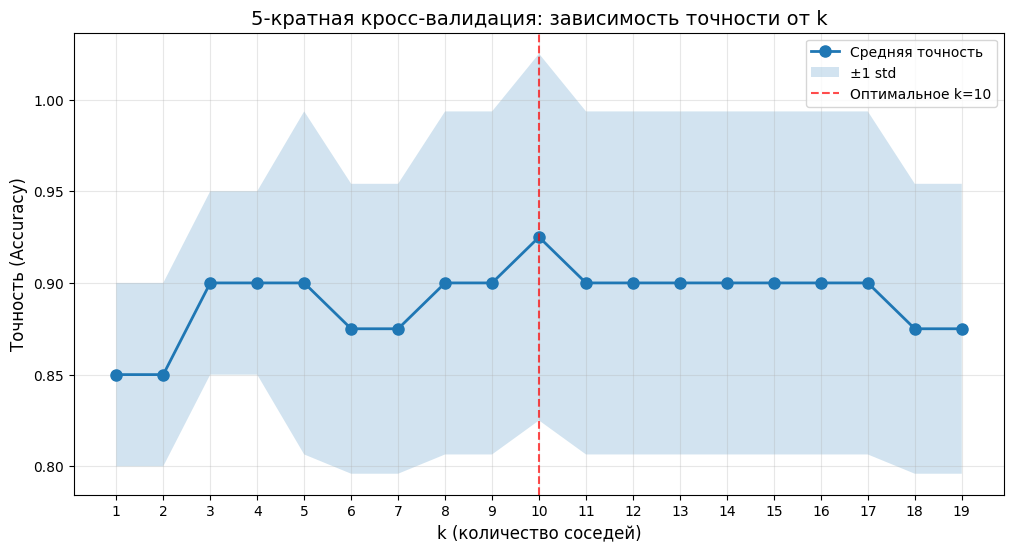

In [42]:
%matplotlib inline

plt.figure(figsize=(12, 6))

# График средней точности с доверительным интервалом
plt.plot(k_values, mean_scores, marker='o', linewidth=2, markersize=8, label='Средняя точность')
plt.fill_between(k_values, 
                 np.array(mean_scores) - np.array(std_scores),
                 np.array(mean_scores) + np.array(std_scores), 
                 alpha=0.2, label='±1 std')

plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'Оптимальное k={best_k}')
plt.xlabel('k (количество соседей)', fontsize=12)
plt.ylabel('Точность (Accuracy)', fontsize=12)
plt.title(f'{cv_folds}-кратная кросс-валидация: зависимость точности от k', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.show()

In [43]:
%time
# Обучаем модель с оптимальным k на всех данных (для последующих прогнозов)
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_scaled, y)

# Повторная кросс-валидация с полным набором метрик
scoring_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
cv_results = cross_validate(final_knn, X_scaled, y, cv=skf, 
                           scoring=scoring_metrics, return_train_score=False)

print("Результаты кросс-валидации для лучшей модели:")
print("="*50)
for metric in scoring_metrics:
    metric_name = metric.replace('_macro', '')
    mean_score = cv_results[f'test_{metric}'].mean()
    std_score = cv_results[f'test_{metric}'].std()
    print(f"{metric_name.capitalize():12s}: {mean_score:.3f} ± {std_score:.3f}")

CPU times: total: 0 ns
Wall time: 3.1 μs
Результаты кросс-валидации для лучшей модели:
Accuracy    : 0.925 ± 0.100
Precision   : 0.937 ± 0.091
Recall      : 0.900 ± 0.133
F1          : 0.905 ± 0.126


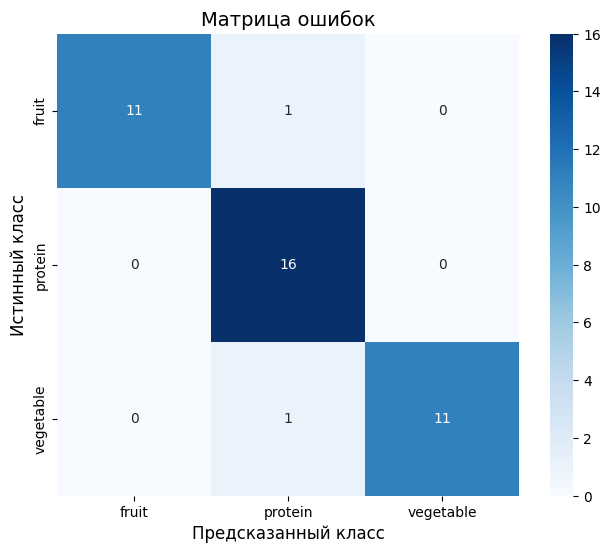


Детальный отчёт по каждому классу:
              precision    recall  f1-score   support

       fruit       1.00      0.92      0.96        12
     protein       0.89      1.00      0.94        16
   vegetable       1.00      0.92      0.96        12

    accuracy                           0.95        40
   macro avg       0.96      0.94      0.95        40
weighted avg       0.96      0.95      0.95        40



In [44]:
# Предсказания на всей выборке
y_pred = final_knn.predict(X_scaled)

# Матрица ошибок
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=final_knn.classes_, 
            yticklabels=final_knn.classes_,
            square=True)

plt.xlabel('Предсказанный класс', fontsize=12)
plt.ylabel('Истинный класс', fontsize=12)
plt.title('Матрица ошибок', fontsize=14)
plt.show()

# Детальный отчёт
print("\nДетальный отчёт по каждому классу:")
print(classification_report(y, y_pred, target_names=final_knn.classes_))

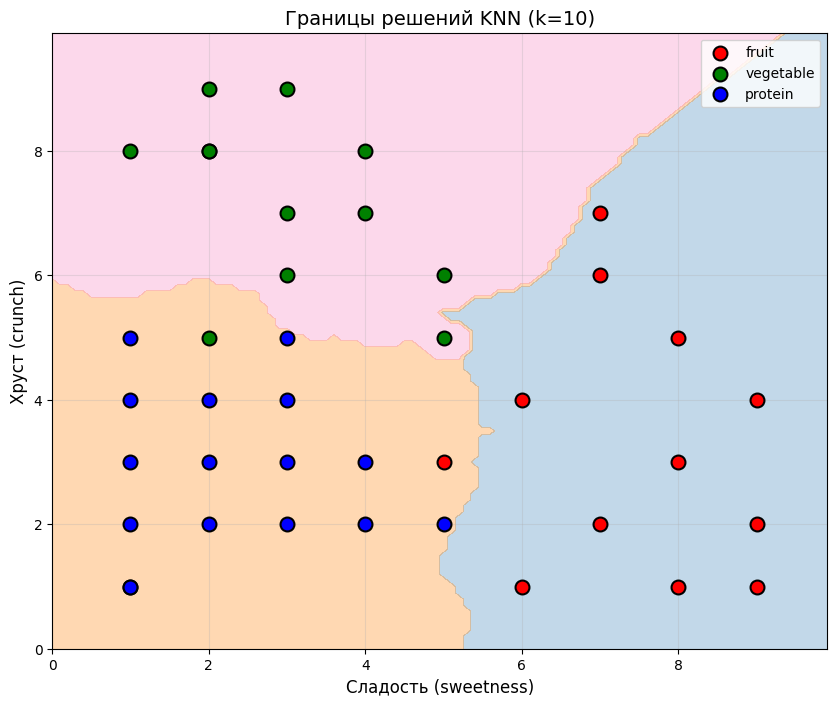

In [45]:
%matplotlib inline

def plot_decision_boundaries(X_original, y, model, scaler, title):
    """Визуализация границ классификации"""
    h = 0.1  # шаг сетки
    
    # Убеждаемся, что X_original — это numpy array
    if isinstance(X_original, pd.DataFrame):
        X_original = X_original.values
    
    # Преобразуем y в numpy array
    y = np.array(y)
    
    # Определяем границы сетки
    x_min, x_max = X_original[:, 0].min() - 1, X_original[:, 0].max() + 1
    y_min, y_max = X_original[:, 1].min() - 1, X_original[:, 1].max() + 1
    
    # Создаём сетку
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Масштабируем точки сетки
    grid_points = scaler.transform(np.c_[xx.ravel(), yy.ravel()])
    
    # Предсказываем для всех точек сетки
    Z_strings = model.predict(grid_points)
    
    # Преобразуем строки в числа для contourf
    unique_classes = model.classes_
    class_to_num = {cls: i for i, cls in enumerate(unique_classes)}
    Z_numeric = np.array([class_to_num[cls] for cls in Z_strings])
    Z_numeric = Z_numeric.reshape(xx.shape)
    
    # Рисуем
    plt.figure(figsize=(10, 8))
    
    # Используем числовую сетку для contourf
    contour_plot = plt.contourf(xx, yy, Z_numeric, alpha=0.3, 
                                 levels=np.arange(-0.5, len(unique_classes), 1),
                                 cmap='Set1')
    
    # Отображаем исходные точки
    colors = {'fruit': 'red', 'vegetable': 'green', 'protein': 'blue'}
    for class_name, color in colors.items():
        if class_name in unique_classes:
            mask = y == class_name
            subset = X_original[mask]
            if len(subset) > 0:
                plt.scatter(subset[:, 0], subset[:, 1], 
                           c=color, label=class_name, edgecolors='black', 
                           s=100, linewidth=1.5, zorder=5)
    
    plt.xlabel('Сладость (sweetness)', fontsize=12)
    plt.ylabel('Хруст (crunch)', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Визуализация
plot_decision_boundaries(X, y, final_knn, scaler, 
                        f'Границы решений KNN (k={best_k})')


Результаты классификации новых объектов:
 sweetness  crunch predicted_class
         8       2           fruit
         3       8       vegetable
         2       3         protein
         5       5       vegetable
         9       1           fruit
         1       9       vegetable
         1       2         protein


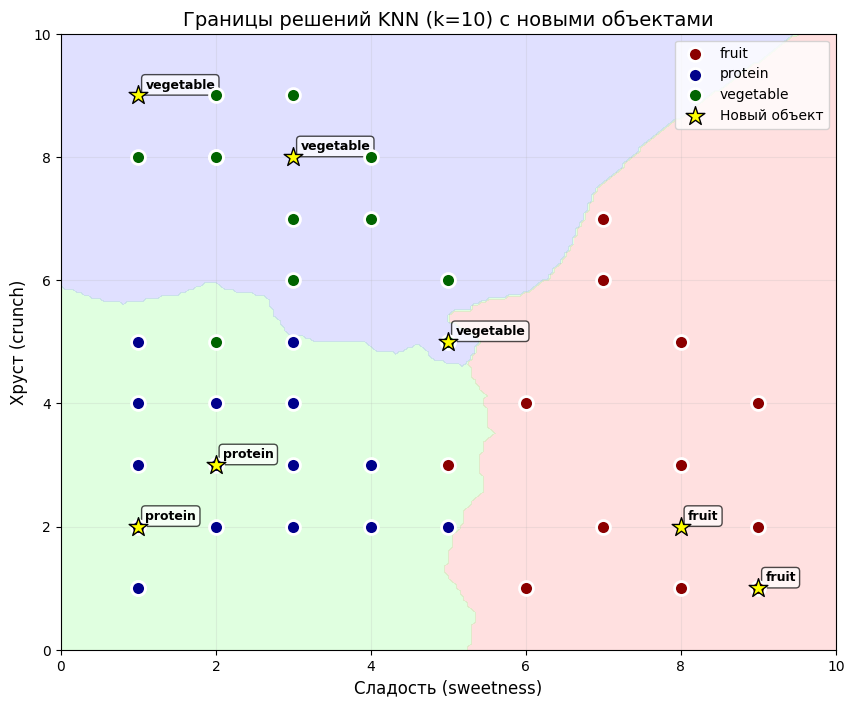

In [46]:
%matplotlib inline

# Создаём тестовые продукты
test_products = np.array([
    [8, 2],   # Ожидаем: fruit
    [3, 8],   # Ожидаем: vegetable
    [2, 3],   # Ожидаем: protein
    [5, 5],   # Пограничный случай
    [9, 1],   # Фрукт
    [1, 9],   # Овощ
    [1, 2],   # Протеин
])

# Нормализуем тестовые данные
test_products_scaled = scaler.transform(test_products)

# Предсказываем
predictions = final_knn.predict(test_products_scaled)

# Выводим результаты
results_df = pd.DataFrame(test_products, columns=['sweetness', 'crunch'])
results_df['predicted_class'] = predictions

print("\nРезультаты классификации новых объектов:")
print("="*45)
print(results_df.to_string(index=False))

# Визуализация с новыми точками
def plot_with_new_points(X_original, y, model, scaler, new_points, predictions, title):
    """Визуализация с добавлением новых точек"""
    
    X_original = np.array(X_original)
    y = np.array(y)
    
    # Создаём сетку
    x_min, x_max = X_original[:, 0].min() - 1, X_original[:, 0].max() + 1
    y_min, y_max = X_original[:, 1].min() - 1, X_original[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    # Масштабируем и предсказываем
    grid_scaled = scaler.transform(np.c_[xx.ravel(), yy.ravel()])
    Z_strings = model.predict(grid_scaled)
    
    # Преобразуем в числа
    unique_classes = model.classes_
    class_to_num = {cls: i for i, cls in enumerate(unique_classes)}
    Z_numeric = np.array([class_to_num[cls] for cls in Z_strings])
    Z_numeric = Z_numeric.reshape(xx.shape)
    
    # Рисуем
    plt.figure(figsize=(10, 8))
    from matplotlib.colors import ListedColormap
    cmap_contour = ListedColormap(['#FF9999', '#99FF99', '#9999FF'])
    plt.contourf(xx, yy, Z_numeric, alpha=0.3, cmap=cmap_contour,
                 levels=np.arange(-0.5, len(unique_classes), 1))
    
    # Исходные точки
    colors_map = {'fruit': 'darkred', 'vegetable': 'darkgreen', 'protein': 'darkblue'}
    for cls in unique_classes:
        mask = y == cls
        plt.scatter(X_original[mask, 0], X_original[mask, 1], 
                   c=colors_map.get(cls, 'black'), label=cls, 
                   edgecolors='white', s=100, linewidth=2, zorder=5)
    
    # Новые точки
    for i, (point, pred) in enumerate(zip(new_points, predictions)):
        plt.scatter(point[0], point[1], c='yellow', edgecolors='black', 
                   s=200, marker='*', zorder=10, 
                   label='Новый объект' if i == 0 else "")
        # Добавляем подпись
        plt.annotate(pred, (point[0], point[1]), 
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=9, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
    
    plt.xlabel('Сладость (sweetness)', fontsize=12)
    plt.ylabel('Хруст (crunch)', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.2)
    plt.show()

# Рисуем финальную визуализацию
plot_with_new_points(X, y, final_knn, scaler, 
                     test_products, predictions,
                     f'Границы решений KNN (k={best_k}) с новыми объектами')

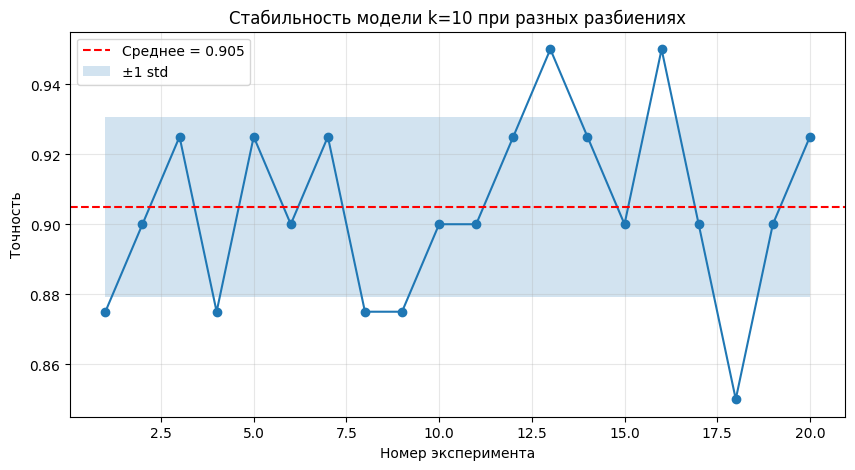

Средняя точность: 0.905 ± 0.026


In [47]:
%matplotlib inline

# Анализ стабильности при разных разбиениях
k_fixed = best_k
n_iterations = 20
scores_iterations = []

for i in range(n_iterations):
    skf_temp = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=i)
    knn_temp = KNeighborsClassifier(n_neighbors=k_fixed)
    scores_temp = cross_val_score(knn_temp, X_scaled, y, cv=skf_temp, scoring='accuracy')
    scores_iterations.append(scores_temp.mean())

plt.figure(figsize=(10, 5))
plt.plot(range(1, n_iterations + 1), scores_iterations, marker='o', linestyle='-')
plt.axhline(y=np.mean(scores_iterations), color='r', linestyle='--', label=f'Среднее = {np.mean(scores_iterations):.3f}')
plt.fill_between(range(1, n_iterations + 1), 
                 np.mean(scores_iterations) - np.std(scores_iterations),
                 np.mean(scores_iterations) + np.std(scores_iterations), 
                 alpha=0.2, label='±1 std')
plt.xlabel('Номер эксперимента')
plt.ylabel('Точность')
plt.title(f'Стабильность модели k={best_k} при разных разбиениях')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Средняя точность: {np.mean(scores_iterations):.3f} ± {np.std(scores_iterations):.3f}")

In [48]:
print(f"""
1. Анализ данных:
   - Размер выборки: {X.shape[0]} объектов
   - Количество признаков: {X.shape[1]}
   - Распределение классов: {dict(df['class'].value_counts())}

2. Результаты кросс-валидации:
   - Оптимальное количество соседей: k = {best_k}
   - Максимальная точность: {best_score:.3f}
   - Модель стабильна (стандартное отклонение: {np.mean(std_scores):.3f})

3. Качество классификации:
   - Метрики получены с помощью {cv_folds}-кратной кросс-валидации
   - Это позволяет избежать переобучения и даёт объективную оценку

4. Рекомендации:
   - Модель готова к использованию на новых данных
   - Для улучшения качества требуется больше размеченных данных
   - Следует проверить другие методы нормализации признаков
""")


1. Анализ данных:
   - Размер выборки: 40 объектов
   - Количество признаков: 2
   - Распределение классов: {'protein': np.int64(16), 'fruit': np.int64(12), 'vegetable': np.int64(12)}

2. Результаты кросс-валидации:
   - Оптимальное количество соседей: k = 10
   - Максимальная точность: 0.925
   - Модель стабильна (стандартное отклонение: 0.082)

3. Качество классификации:
   - Метрики получены с помощью 5-кратной кросс-валидации
   - Это позволяет избежать переобучения и даёт объективную оценку

4. Рекомендации:
   - Модель готова к использованию на новых данных
   - Для улучшения качества требуется больше размеченных данных
   - Следует проверить другие методы нормализации признаков

